## Importing leraries

In [1]:
!pip install -q rasterio
print("Dependencies installed successfully!")

Dependencies installed successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import rasterio
import tensorflow as tf
from tensorflow import keras
from keras import layers, Model

In [3]:
import os
import tifffile as tiff
from glob import glob

In [4]:
TRAIN_HR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/train/HR_0.5m"
TRAIN_LR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/train/LR_1m"

VAL_HR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/val/HR_0.5m"
VAL_LR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/val/LR_1m"

TEST_HR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/test/HR_0.5m"
TEST_LR = "/kaggle/input/datasets/dozeradi007/patch-dataset-for-paired-hr-lr-satellite-imagery/patch_dataset/test/LR_1m"

In [5]:
import warnings
warnings.filterwarnings('ignore')

## Data preprocessing

In [6]:
def get_image_pairs(hr_root, lr_root):

    hr_paths = sorted(glob(os.path.join(hr_root, "*", "*.tif")))
    lr_paths = sorted(glob(os.path.join(lr_root, "*", "*.tif")))
    # assert len(hr_paths) == len(lr_paths), "HR and LR image count mismatch!"
    # return hr_paths, lr_paths
    
    good_hr = []
    good_lr = []

    for hr, lr in zip(hr_paths, lr_paths):

        hr_img = tiff.imread(hr)
        lr_img = tiff.imread(lr)

        if hr_img.shape == (512,512,3) and lr_img.shape == (256,256,3):
            good_hr.append(hr)
            good_lr.append(lr)

    return good_hr, good_lr

In [7]:
train_hr, train_lr = get_image_pairs(TRAIN_HR, TRAIN_LR)
val_hr, val_lr = get_image_pairs(VAL_HR, VAL_LR)

print("Training patches :", len(train_hr))
print("Validation patches :", len(val_hr))

Training patches : 4375
Validation patches : 925


In [8]:
# import tifffile as tiff
sample = tiff.imread(train_hr[0])

print(sample.dtype)
print(sample.min(), sample.max())

uint8
0 240


In [9]:
def load_image(lr_path, hr_path):

    lr = tiff.imread(lr_path.decode())

    hr = tiff.imread(hr_path.decode())

    return lr.astype(np.float32), hr.astype(np.float32)

In [10]:
def preprocess(lr_path, hr_path):
# uses tf.numpy_function to wrap a regular Python/NumPy function (load_image) 
# so it can be used inside a TensorFlow data pipeline
    lr, hr = tf.numpy_function(
        load_image,
        [lr_path, hr_path],
        [tf.float32, tf.float32]
    )

    lr.set_shape([256,256,3])
    hr.set_shape([512,512,3])

    # Normalize and limit to [0, 1]
    lr = tf.clip_by_value(lr / 255.0, 0.0, 1.0)
    hr = tf.clip_by_value(hr / 255.0, 0.0, 1.0)

    return lr, hr

## Defining TensorFlow dataset

In [11]:
# BATCH_SIZE = 32
# BATCH_SIZE = 16
# BATCH_SIZE = 8
BATCH_SIZE = 4

AUTOTUNE = tf.data.AUTOTUNE


train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_lr, train_hr)
)

train_dataset = (
    train_dataset
    .shuffle(1000)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


val_dataset = tf.data.Dataset.from_tensor_slices(
    (val_lr, val_hr)
)

val_dataset = (
    val_dataset
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

I0000 00:00:1790692810.632186      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790692810.635099      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [12]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "edsr_x2.keras",
    monitor="val_loss",
    save_best_only=True
)

earlystop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    # patience=6,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5
    # patience=3
)

## Defining Model Architecture

In [13]:
def residual_block(x, filters=256, res_scale=0.1):
    """ 
    EDSR Residual Block: 
    - Conv2D (3x3) -> ReLU -> Conv2D (3x3) 
    - Residual scaling (res\_scale = 0.1) 
    - Skip connection (Element-wise Addition) 
    - NO Batch Normalization, NO activation after addition 
    """ 
    res = layers.Conv2D(filters, kernel_size=3, padding='same')(x) 
    res = layers.ReLU()(res)
    res = layers.Conv2D(filters, kernel_size=3, padding='same')(res) 
    
    # Apply constant residual scaling factor (0.1) to stabilize wide network training 
    if res_scale is not None: 
        res = layers.Lambda(lambda t: t * res_scale)(res) 
    
    out = layers.Add()([x, res]) 
    
    return out

In [14]:
def upsample_block(x, scale, filters):
    """
    EDSR upsampling block.

    Equivalent to PyTorch:
        nn.Conv2d(filters, filters * scale**2, 3, padding=1)
        nn.PixelShuffle(scale)
        nn.ReLU()

    TensorFlow equivalent:
        Conv2D -> tf.nn.depth_to_space -> ReLU

    Args:
        x: Input tensor, shape (N, H, W, filters)
        scale: Upsampling factor, e.g. 2 or 4
        filters: Number of feature channels before PixelShuffle

    Returns:
        Upsampled tensor, shape (N, H*scale, W*scale, filters)
    """

    if scale not in [2,3,4]:
        raise ValueError("scale must be one of 2, 3, or 4")
    if scale == 4:
        # x2 followed by x2
        for _ in range(2):
            x = layers.Conv2D(filters * 4, kernel_size=3, padding='same')(x)
            x = layers.Lambda(lambda t: tf.nn.depth_to_space(t, block_size=2))(x)
            x = layers.ReLU()(x)

    else:
        x = layers.Conv2D(filters * (scale ** 2), kernel_size=3, padding='same')(x)
        x = layers.Lambda(lambda t: tf.nn.depth_to_space(t, block_size=scale))(x)
        x = layers.ReLU()(x)

    return x

In [15]:
def build_edsr(scale=2, filters=256, res_blocks=32, res_scale=0.1, channels=3, input_shape=(None, None, 3)):
    
    """ 
    Builds the Single-Scale EDSR model architecture. 
    Paper defaults: B=32 residual blocks, F=256 filters, res_scale=0.1 
    """
    inputs=layers.Input(shape=input_shape)
    
    # Head Convolutional (feature Extraction)
    x_head=layers.Conv2D(filters, kernel_size=3, padding='same')(inputs)
    
    # Residual blocks (32 blocks)
    x=x_head
    for _ in range(res_blocks):
        x=residual_block(x, filters, res_scale)

    # Global residual connection
    x_body=layers.Conv2D(filters, kernel_size=3, padding='same')(x)
    x=layers.Add()([x_head, x_body])

    #Tail upsampling
    x=upsample_block(x, scale, filters)

    #final reconstruction
    outputs=layers.Conv2D(channels, kernel_size=3, padding='same')(x)
    
    return Model(inputs=inputs, outputs=outputs, name=f"EDSR_x{scale}")

## Training model

In [16]:
EPOCHS=1
LR=1e-4
SCALE=2
FILTERS=64
RES_BLOCKS=16
RES_SCALE=0.1

In [17]:
def psnr_metric(y_true, y_pred):
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))

In [20]:
# Uses both the GPUs
strategy = tf.distribute.MirroredStrategy()

print("Number of devices:", strategy.num_replicas_in_sync)

with strategy.scope():
    edsr_x2=build_edsr(scale=SCALE, filters=FILTERS, res_blocks=RES_BLOCKS, res_scale=RES_SCALE)     # model
    edsr_x2.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss='mae',
        metrics=[
            'mae',
            'mse',
            psnr_metric
        ]
    )

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')
Number of devices: 2


In [21]:
edsr_x2.summary()

Model: "EDSR_x2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, None,      │      1,792 │ input_layer_1[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, None,      │     36,928 │ conv2d_36[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_17 (ReLU)     │ (None, None,      │          0 │ conv2d_37[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, None,      │     36,928 │ re_lu_17[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_17 (Lambda)  │ (None, None,      │          0 │ conv2d_38[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_17 (Add)        │ (None, None,      │          0 │ conv2d_36[0][0],  │
│                     │ None, 64)         │            │ lambda_17[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, None,      │     36,928 │ add_17[0][0]      │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, None,      │          0 │ conv2d_39[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, None,      │     36,928 │ re_lu_18[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_18 (Lambda)  │ (None, None,      │          0 │ conv2d_40[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, None,      │          0 │ add_17[0][0],     │
│                     │ None, 64)         │            │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, None,      │     36,928 │ add_18[0][0]      │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, None,      │          0 │ conv2d_41[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, None,      │     36,928 │ re_lu_19[0][0]    │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_19 (Lambda)  │ (None, None,      │          0 │ conv2d_42[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, None,      │          0 │ add_18[0][0],   

 Total params: 1,369,859 (5.23 MB)

 Trainable params: 1,369,859 (5.23 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history = edsr_x2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[checkpoint,
               earlystop,
               reduce_lr]
)

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Redu

## Testing

In [23]:
test_hr, test_lr = get_image_pairs(TEST_HR, TEST_LR)

In [24]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (test_lr, test_hr)
)

test_dataset = (
    test_dataset
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

In [29]:
lr, hr = next(iter(test_dataset))

# Bicubic baseline
bicubic = tf.image.resize(lr, [512, 512], method="bicubic")

# SRCNN prediction
sr = edsr_x2.predict(lr, verbose=0)

# PSNR
bicubic_psnr = tf.image.psnr(hr, bicubic, max_val=1.0)
edsr_psnr = tf.image.psnr(hr, sr, max_val=1.0)

print("Bicubic PSNR:", bicubic_psnr.numpy().mean())
print("EDSR PSNR :", edsr_psnr.numpy().mean())

Bicubic PSNR: 31.091482
EDSR PSNR : 32.554966


In [31]:
def plot_image(org_img, bicubic_img, sr_img):
    # Convert TensorFlow tensor to NumPy
    if tf.is_tensor(org_img):
        org_img = org_img.numpy()

    if tf.is_tensor(bicubic_img):
        bicubic_img = bicubic_img.numpy()

    # Remove batch dimension if present
    org_img = np.squeeze(org_img)
    bicubic_img = np.squeeze(bicubic_img)
    sr_img = np.squeeze(sr_img)

    # Convert CHW -> HWC if necessary
    if org_img.ndim == 3 and org_img.shape[0] in [1, 3]:
        org_img = org_img.transpose(1, 2, 0)

    if bicubic_img.ndim == 3 and bicubic_img.shape[0] in [1, 3]:
        bicubic_img = bicubic_img.transpose(1, 2, 0)

    if sr_img.ndim == 3 and sr_img.shape[0] in [1, 3]:
        sr_img = sr_img.transpose(1, 2, 0)

    # Keep values in the normalized [0, 1] range
    org_img = np.clip(org_img, 0, 1)
    bicubic_img = np.clip(bicubic_img, 0, 1)
    sr_img = np.clip(sr_img, 0, 1)

    # Plot
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(org_img)
    plt.title("Original HR Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(bicubic_img)
    plt.title("Bicubic Image")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(sr_img)
    plt.title("EDSR Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


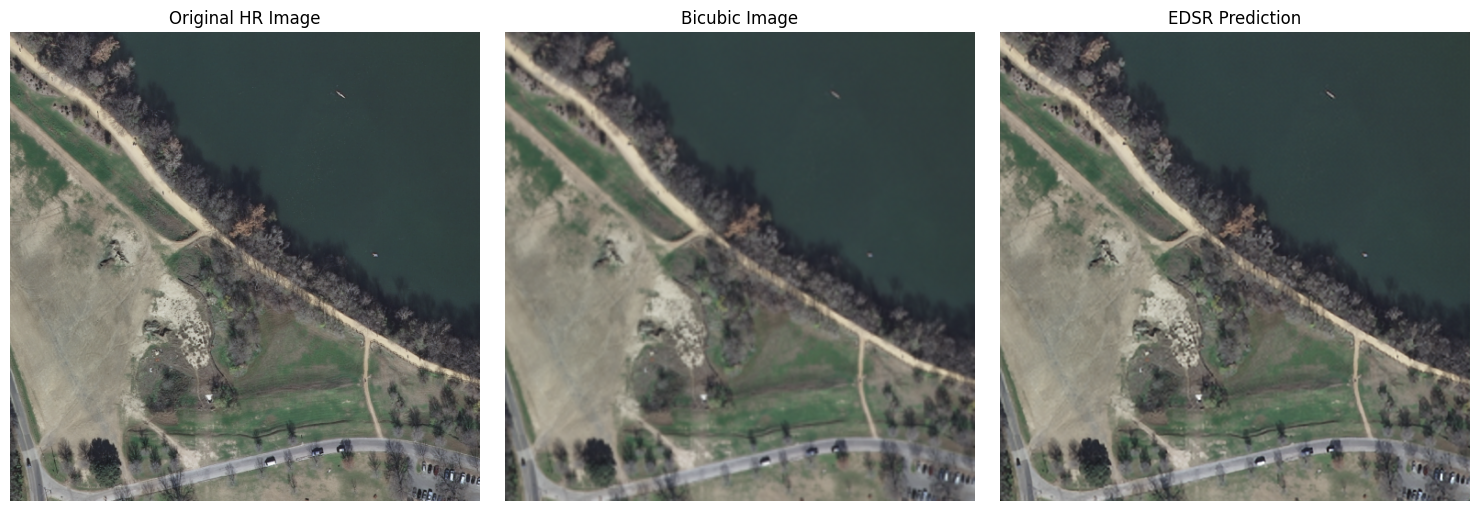

In [38]:
plot_image(hr[1],
           bicubic[1],
           sr[1])